# Explore 3D medical images

Load a few NIfTI volumes and plot mid-slices + intensity histogram.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

ROOT = Path(".")
TRAIN = ROOT / "train"
VAL = ROOT / "validation"
TEST = ROOT / "test"

## Counts

In [2]:
def list_images(folder: Path):
    """Return image paths (`*_0000.nii.gz`)."""
    return sorted(folder.rglob("*_0000.nii.gz"))


def label_path(image_path: Path) -> Path:
    """Image `quiz_X_Y_0000.nii.gz` -> label `quiz_X_Y.nii.gz`."""
    return image_path.with_name(image_path.name.replace("_0000.nii.gz", ".nii.gz"))


for name, folder in [("train", TRAIN), ("validation", VAL), ("test", TEST)]:
    imgs = list_images(folder)
    print(f"{name:12s}: {len(imgs)} images")

print("\nTrain by subtype:")
for sub in sorted(TRAIN.glob("subtype*")):
    print(f"  {sub.name}: {len(list_images(sub))} images")

train       : 252 images
validation  : 36 images
test        : 72 images

Train by subtype:
  subtype0: 62 images
  subtype1: 106 images
  subtype2: 84 images


## Load one sample

In [3]:
img_path = list_images(TRAIN / "subtype0")[0]
lbl_path = label_path(img_path)

img = nib.load(img_path).get_fdata()
lbl = nib.load(lbl_path).get_fdata()

print("image:", img_path.name, img.shape, img.dtype)
print("label:", lbl_path.name, lbl.shape, "unique:", np.unique(lbl))
print("intensity range:", float(img.min()), "->", float(img.max()))

image: quiz_0_041_0000.nii.gz (161, 116, 106) float64
label: quiz_0_041.nii.gz (161, 116, 106) unique: [0. 1. 2.]
intensity range: -1034.0000610351562 -> 1727.000045131892


## Mid-slice views (axial / coronal / sagittal)

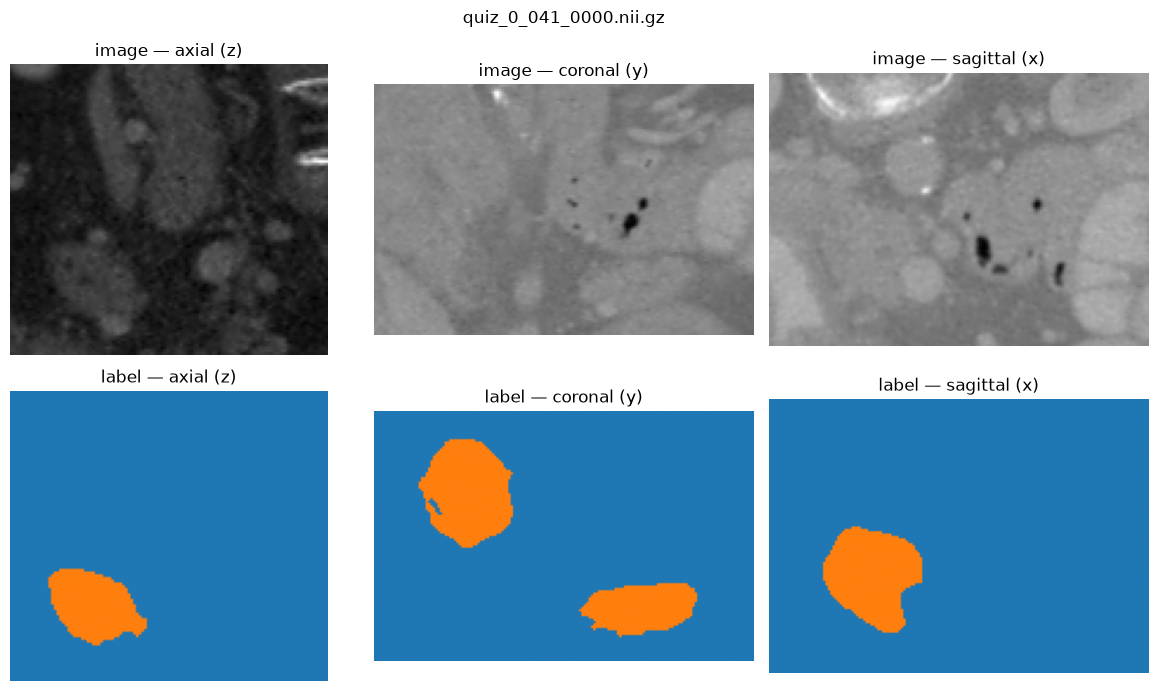

In [4]:
def mid_slices(vol):
    z, y, x = [s // 2 for s in vol.shape]
    return {
        "axial (z)": vol[z, :, :],
        "coronal (y)": vol[:, y, :],
        "sagittal (x)": vol[:, :, x],
    }


fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, (title, sl) in zip(axes[0], mid_slices(img).items()):
    ax.imshow(sl.T, cmap="gray", origin="lower")
    ax.set_title(f"image — {title}")
    ax.axis("off")

for ax, (title, sl) in zip(axes[1], mid_slices(lbl).items()):
    ax.imshow(sl.T, cmap="tab10", origin="lower", vmin=0, vmax=9)
    ax.set_title(f"label — {title}")
    ax.axis("off")

plt.suptitle(img_path.name)
plt.tight_layout()
plt.show()

## Overlay + intensity histogram

In [ ]:
z = img.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img[z].T, cmap="gray", origin="lower")
axes[0].imshow(np.ma.masked_where(lbl[z] == 0, lbl[z]).T, cmap="autumn", alpha=0.45, origin="lower")
axes[0].set_title(f"axial overlay (z={z})")
axes[0].axis("off")

axes[1].hist(img.ravel(), bins=80, color="steelblue", edgecolor="none")
axes[1].set_title("intensity histogram")
axes[1].set_xlabel("intensity")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## Quick look at one test image

In [ ]:
test_path = list_images(TEST)[0]
test_img = nib.load(test_path).get_fdata()
print(test_path.name, test_img.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (title, sl) in zip(axes, mid_slices(test_img).items()):
    ax.imshow(sl.T, cmap="gray", origin="lower")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(test_path.name)
plt.tight_layout()
plt.show()